In [1]:
import pde_models
import torch
from matplotlib import pyplot as plt

In [64]:
d = 2
#a = 0.7 + 0.5*torch.rand(d)
a = torch.ones(d)
L = 3.5

pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a)
spatial_domain = L*torch.ones((d,2))
spatial_domain[:,0] *= -1.0

In [82]:
z = pde_model.estimate_Z_2(spatial_domain, n_samples_1d=10_000_000)
z

tensor(9.2455)

In [26]:
d = 2
a = 0.7 + 0.5*torch.rand(d)
pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a)

L = 3.0
spatial_domain = L*torch.ones((d,2))
spatial_domain[:,0] *= -1.0

n_samples = 200_000
z_uni = pde_model.estimate_Z(spatial_domain, n_samples, proposal="uniform")
print(z_uni)
z_gauss = pde_model.estimate_Z(spatial_domain, n_samples, proposal="gaussian")
print(z_gauss)

9.034084439277649
9.069458961486816


In [ ]:
d_min = 10
d_max = 20
a = 0.7 + 0.5*torch.rand(d_max)
L = 3.0

n_samples_min = 1_000_000
n = 10

data_uni = torch.zeros((10, d_max-d_min))
data_gauss = torch.zeros((10, d_max-d_min))

dims = [*range(d_min,d_max)]
for i in range(n):
    n_samples = n_samples_min * (i+1)

    for d in range(d_min,d_max):
        print(n_samples, d)

        pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a[:d])

        spatial_domain = L*torch.ones((d,2))
        spatial_domain[:,0] *= -1.0

        z_uni = pde_model.estimate_Z(spatial_domain, n_samples, proposal="uniform")
        data_uni[i, d-d_min] = z_uni
        #print(d, z_uni)
        #z_gauss = pde_model.estimate_Z(spatial_domain, n_samples, proposal="gaussian")
        #data_gauss[i, d-d_min] = z_gauss
        #print(d, z_gauss)

1000000 10
1000000 11
1000000 12
1000000 13
1000000 14
1000000 15
1000000 16
1000000 17
1000000 18
1000000 19
2000000 10
2000000 11
2000000 12
2000000 13
2000000 14
2000000 15
2000000 16
2000000 17
2000000 18
2000000 19
3000000 10
3000000 11
3000000 12
3000000 13
3000000 14
3000000 15
3000000 16
3000000 17
3000000 18
3000000 19
4000000 10
4000000 11
4000000 12
4000000 13
4000000 14
4000000 15
4000000 16
4000000 17
4000000 18
4000000 19
5000000 10
5000000 11
5000000 12
5000000 13
5000000 14
5000000 15
5000000 16
5000000 17
5000000 18
5000000 19
6000000 10
6000000 11
6000000 12
6000000 13
6000000 14
6000000 15
6000000 16
6000000 17
6000000 18
6000000 19
7000000 10
7000000 11
7000000 12
7000000 13
7000000 14
7000000 15
7000000 16
7000000 17
7000000 18
7000000 19
8000000 10
8000000 11
8000000 12
8000000 13
8000000 14
8000000 15
8000000 16
8000000 17
8000000 18
8000000 19
9000000 10
9000000 11
9000000 12
9000000 13
9000000 14
9000000 15
9000000 16
9000000 17
9000000 18
9000000 19
10000000 1

In [41]:
data_uni[0]

tensor([6.5667e+04, 1.7148e+05, 5.3889e+05, 1.5310e+06, 5.2143e+06, 1.5453e+07,
        4.9808e+07, 1.5489e+08, 5.4178e+08, 9.9005e+08])

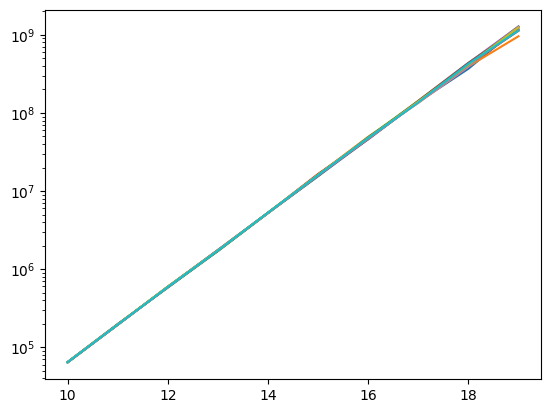

In [ ]:
plt.close()
for j in range(n):
    plt.plot(dims, data_uni[j,:])
    #plt.plot(dims, data_gauss[j,:])
plt.yscale('log')
plt.show()

# just 1d case

In [106]:
a_list = torch.linspace(0.7, 1.2, 6)
L_list = torch.linspace(2.0, 10.0, 17)
a_list, L_list

(tensor([0.7000, 0.8000, 0.9000, 1.0000, 1.1000, 1.2000]),
 tensor([ 2.0000,  2.5000,  3.0000,  3.5000,  4.0000,  4.5000,  5.0000,  5.5000,
          6.0000,  6.5000,  7.0000,  7.5000,  8.0000,  8.5000,  9.0000,  9.5000,
         10.0000]))

In [ ]:
d = 1
n_as = 6
n_Ls = 17

a_list = torch.linspace(0.7, 1.2, n_as)
L_list = torch.linspace(2.0, 10.0, n_Ls)
n_samples_list = [10_000_000]

n_ss = len(n_samples_list)
data_1d_int = torch.zeros((n_as, n_Ls, n_ss))
for i,a in enumerate(a_list):
    pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a)
    for j,L in enumerate(L_list):
        spatial_domain = torch.tensor([[-L,L]])
        for k, n_samples in enumerate(n_samples_list):
            z_uni = pde_model.estimate_Z(spatial_domain, n_samples, proposal="uniform")
            data_1d_int[i,j,k] = z_uni

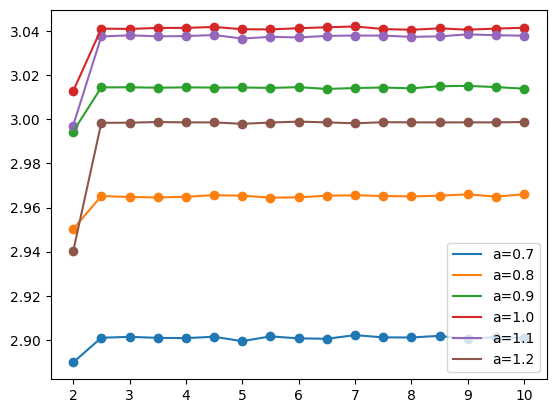

In [119]:
plt.close()
for i in range(len(a_list)):
    plt.plot(L_list, data_1d_int[i,:,-1], label=f"a={a_list[i]:.01f}")
    plt.scatter(L_list, data_1d_int[i,:,-1])
#plt.yscale('log')
plt.legend()
plt.show()

In [118]:
data_1d_int[3,:,-1]

tensor([3.0128, 3.0412, 3.0410, 3.0415, 3.0415, 3.0420, 3.0409, 3.0408, 3.0414,
        3.0418, 3.0422, 3.0410, 3.0407, 3.0413, 3.0407, 3.0412, 3.0416])

In [60]:
d = 1
L = 3.5
n_samples = 10_000_000
n_as = 100

a_list = torch.linspace(0.0, 2.5, n_as)

spatial_domain = torch.tensor([[-L,L]])
data_1d_int = torch.zeros(n_as)
for i,a in enumerate(a_list):
    pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a)
    z_uni = pde_model.estimate_Z(spatial_domain, n_samples, proposal="uniform")
    data_1d_int[i] = z_uni

/tmp/ipykernel_7880/118032093.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


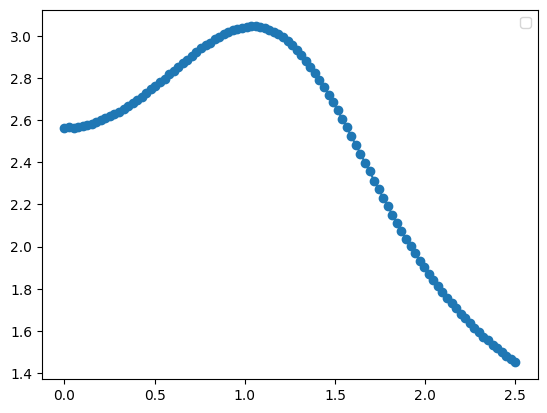

In [61]:
plt.close()
plt.plot(a_list, data_1d_int)
plt.scatter(a_list, data_1d_int)
#plt.yscale('log')
plt.legend()
plt.show()

In [82]:
d = 1
L = 3.5
n_samples = 10_000_000
n_trials = 3
n_as = 100

#a_list = torch.linspace(0.0, 2.5, n_as)
a_list = torch.linspace(0.85, 1.15, n_as)

spatial_domain = torch.tensor([[-L,L]])
data_1d_int = torch.zeros((n_trials, n_as))
for i,a in enumerate(a_list):
    pde_model = pde_models.SmoluchowskiDoubleWell(d=d, beta=1.0, a=a)
    for j in range(n_trials):
        z_uni = pde_model.estimate_Z(spatial_domain, n_samples, proposal="uniform")
        data_1d_int[j,i] = z_uni

[-1.04796078  1.61831675  0.03337087  2.43775052]
        3         2
-1.048 x + 1.618 x + 0.03337 x + 2.438


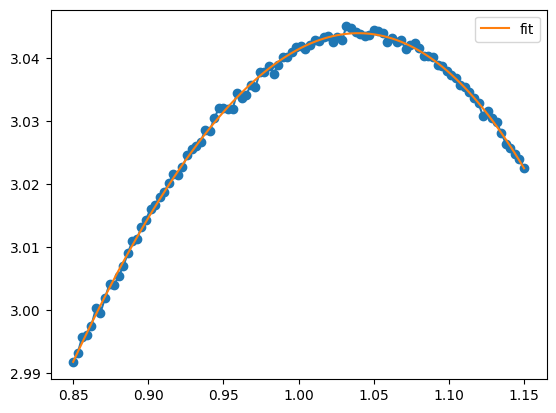

In [84]:
y = data_1d_int.mean(dim=0)

import numpy as np
degree = 3
coeffs = np.polyfit(a_list.numpy(), y.numpy(), degree)
poly_func = np.poly1d(coeffs)
# now poly_func is callable
print(coeffs)
print(poly_func) 



plt.close()
plt.plot(a_list, y)
plt.scatter(a_list, y)
plt.plot(a_list, poly_func(a_list), label="fit")
#plt.yscale('log')
plt.legend()
plt.show()

In [81]:
d = 10
2.99**d, 2.98**d

(57109.96358479342, 55228.4227795293)

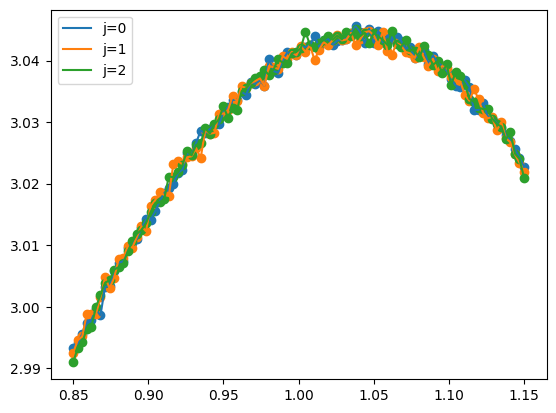

In [56]:
plt.close()
for j in range(n_trials):
    plt.plot(a_list, data_1d_int[j], label=f"j={j}")
    plt.scatter(a_list, data_1d_int[j])
#plt.yscale('log')
plt.legend()
plt.show()